In [ ]:
!pip install -q pycbc tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 15.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from pycbc.waveform import get_td_waveform
from scipy.ndimage import uniform_filter1d
from scipy.signal import savgol_filter, butter, filtfilt
from scipy.stats import pearsonr

import tensorflow as tf
from tensorflow.keras import layers, models

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("TensorFlow version:", tf.__version__)

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


TensorFlow version: 2.20.0


In [ ]:
sample_rate = 4096
delta_t = 1.0 / sample_rate

mass1 = 36
mass2 = 29
distance = 410

hp, hc = get_td_waveform(
    approximant="IMRPhenomD",
    mass1=mass1,
    mass2=mass2,
    spin1z=0,
    spin2z=0,
    distance=distance,
    delta_t=delta_t,
    f_lower=20
)

t = np.array(hp.sample_times)
y = np.array(hp)

mask = (t >= -1.0) & (t <= 0.05)

t_crop = t[mask]
clean = y[mask]
clean = clean / np.max(np.abs(clean))

print("Clean waveform shape:", clean.shape)

Clean waveform shape: (4301,)


In [ ]:
np.random.seed(42)

num_train = 2500
num_test = 500

X = []
Y = []

for i in range(num_train + num_test):
    noise_level = np.random.uniform(0.1, 0.8)
    noise = noise_level * np.random.normal(0, 1, size=len(clean))
    noisy_signal = clean + noise

    X.append(noisy_signal)
    Y.append(clean)

X = np.array(X)
Y = np.array(Y)

# Add channel dimension for Conv1D
X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

X_train = X[:num_train]
Y_train = Y[:num_train]

X_test = X[num_train:]
Y_test = Y[num_train:]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (2500, 4301, 1)
Y_train: (2500, 4301, 1)
X_test: (500, 4301, 1)
Y_test: (500, 4301, 1)


In [ ]:
input_shape = X_train.shape[1:]

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv1D(32, kernel_size=9, padding="same", activation="relu"),
    layers.Conv1D(32, kernel_size=9, padding="same", activation="relu"),

    layers.Conv1D(16, kernel_size=9, padding="same", activation="relu"),
    layers.Conv1D(16, kernel_size=9, padding="same", activation="relu"),

    layers.Conv1D(8, kernel_size=9, padding="same", activation="relu"),

    layers.Conv1D(16, kernel_size=9, padding="same", activation="relu"),
    layers.Conv1D(32, kernel_size=9, padding="same", activation="relu"),

    layers.Conv1D(1, kernel_size=9, padding="same", activation="linear")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4301, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4301, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 4301, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 4301, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 4301, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 4301, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 4301, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 4301, 1)        │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,769 (92.85 KB)

 Trainable params: 23,769 (92.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    verbose=1
)

Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 0.0201 - val_loss: 0.0112
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.0096 - val_loss: 0.0087
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - loss: 0.0084 - val_loss: 0.0081
Epoch 4/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - loss: 0.0079 - val_loss: 0.0078
Epoch 5/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0076 - val_loss: 0.0075
Epoch 6/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - loss: 0.0075 - val_loss: 0.0074
Epoch 7/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0073 - val_loss: 0.0071
Epoch 8/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0071 - val_loss: 0.0070
Epoch 9/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.0070 - val_loss: 0.0069
Epoch 10/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0068 - val_loss: 0.0068
Epoch 11/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 0.0067 - val_loss: 0.0066
Epoch 12/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 0.0066 - val_lo

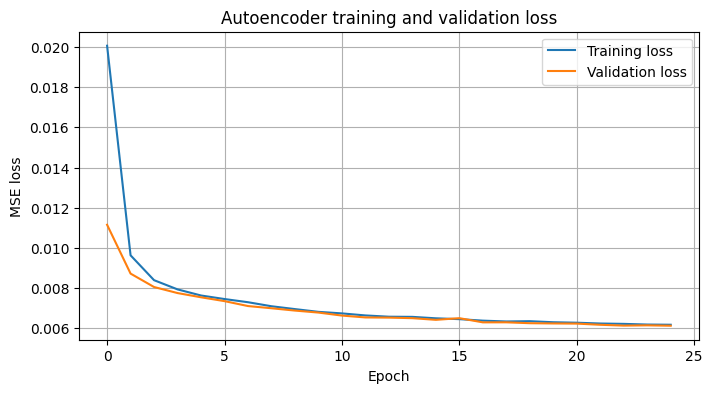

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder training and validation loss")
plt.legend()
plt.grid(True)

plt.savefig("figures/01_autoencoder_training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#The autoencoder training loss decreased rapidly during the first few epochs and then gradually stabilized. The validation loss followed a similar trend and remained close to the training loss, indicating that the model learned a stable denoising mapping without severe overfitting.

In [ ]:
np.random.seed(100)

noise_level = 0.35
noise = noise_level * np.random.normal(0, 1, size=len(clean))
noisy_035 = clean + noise

auto_input = noisy_035[np.newaxis, ..., np.newaxis]
auto_denoised = model.predict(auto_input)[0, :, 0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step


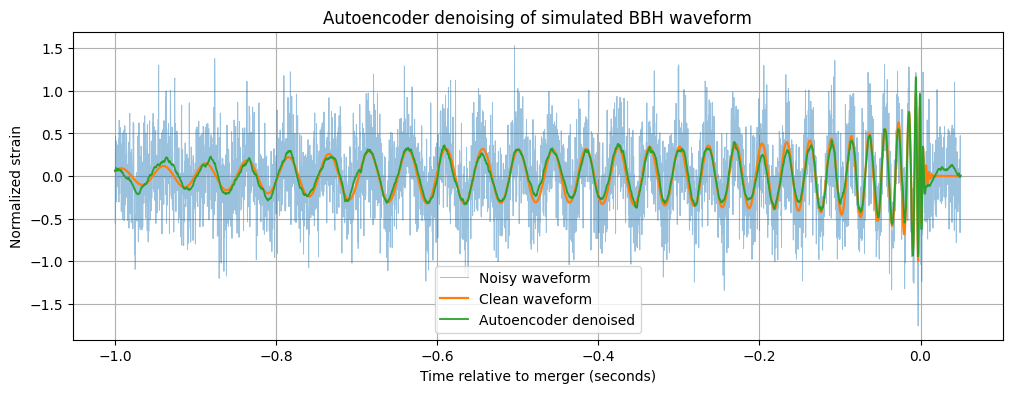

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(t_crop, noisy_035, label="Noisy waveform", linewidth=0.7, alpha=0.45)
plt.plot(t_crop, clean, label="Clean waveform", linewidth=1.6)
plt.plot(t_crop, auto_denoised, label="Autoencoder denoised", linewidth=1.3)

plt.xlabel("Time relative to merger (seconds)")
plt.ylabel("Normalized strain")
plt.title("Autoencoder denoising of simulated BBH waveform")
plt.legend()
plt.grid(True)

plt.savefig("figures/02_autoencoder_denoising_noise_035.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#The trained autoencoder successfully suppresses a large fraction of the added Gaussian noise and reconstructs the overall BBH waveform morphology. The inspiral region is recovered closely, while some deviations remain near the merger region where the waveform changes rapidly. This suggests that the model learns the dominant waveform structure but may require improved training diversity or architecture refinement to better preserve sharp merger features.

In [ ]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def correlation(y_true, y_pred):
    return pearsonr(y_true, y_pred)[0]

def snr_db(clean_signal, test_signal):
    signal_power = np.mean(clean_signal ** 2)
    noise_power = np.mean((clean_signal - test_signal) ** 2)
    return 10 * np.log10(signal_power / noise_power)

def evaluate_method(name, clean_signal, denoised_signal):
    return {
        "Method": name,
        "MSE": mse(clean_signal, denoised_signal),
        "MAE": mae(clean_signal, denoised_signal),
        "Correlation": correlation(clean_signal, denoised_signal),
        "SNR_dB": snr_db(clean_signal, denoised_signal)
    }

In [ ]:
moving_avg = uniform_filter1d(noisy_035, size=15)
savgol = savgol_filter(noisy_035, window_length=31, polyorder=3)

sample_rate = 4096
cutoff_freq = 300

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    return filtfilt(b, a, data)

butter_filtered = butter_lowpass_filter(noisy_035, cutoff_freq, sample_rate)

results = []

results.append(evaluate_method("Noisy input", clean, noisy_035))
results.append(evaluate_method("Moving average", clean, moving_avg))
results.append(evaluate_method("Savitzky-Golay", clean, savgol))
results.append(evaluate_method("Butterworth low-pass", clean, butter_filtered))
results.append(evaluate_method("Autoencoder", clean, auto_denoised))

results_df = pd.DataFrame(results)
results_df

,Method,MSE,MAE,Correlation,SNR_dB
0,Noisy input,0.128438,0.285069,0.543352,-3.535260
1,Moving average,0.010320,0.076615,0.907527,7.414953
2,Savitzky-Golay,0.011414,0.079188,0.900496,6.977258
3,Butterworth low-pass,0.017365,0.104353,0.868688,5.154871
4,Autoencoder,0.003831,0.048839,0.966668,11.718114


In [ ]:
#At a Gaussian noise level of 0.35, the autoencoder outperformed all tested classical filtering baselines. It achieved the lowest MSE and MAE, the highest Pearson correlation with the clean waveform, and the highest SNR. This indicates that the learned denoising model recovered the simulated binary black-hole waveform more accurately than moving average, Savitzky-Golay, and Butterworth low-pass filtering under this controlled noise condition.

In [ ]:
noise_levels = [0.1, 0.25, 0.35, 0.5, 0.75]

all_results = []

for nl in noise_levels:
    np.random.seed(42)
    noise = nl * np.random.normal(0, 1, size=len(clean))
    noisy_signal = clean + noise

    moving_avg_signal = uniform_filter1d(noisy_signal, size=15)
    savgol_signal = savgol_filter(noisy_signal, window_length=31, polyorder=3)
    butter_signal = butter_lowpass_filter(noisy_signal, cutoff_freq, sample_rate)

    auto_input = noisy_signal[np.newaxis, ..., np.newaxis]
    auto_signal = model.predict(auto_input, verbose=0)[0, :, 0]

    for method_name, signal in [
        ("Noisy input", noisy_signal),
        ("Moving average", moving_avg_signal),
        ("Savitzky-Golay", savgol_signal),
        ("Butterworth low-pass", butter_signal),
        ("Autoencoder", auto_signal)
    ]:
        result = evaluate_method(method_name, clean, signal)
        result["Noise_Level"] = nl
        all_results.append(result)

multi_noise_auto_df = pd.DataFrame(all_results)
multi_noise_auto_df

,Method,MSE,MAE,Correlation,SNR_dB,Noise_Level
0,Noisy input,0.009962,0.079530,0.922131,7.568097,0.10
1,Moving average,0.002673,0.026549,0.976940,13.282249,0.10
2,Savitzky-Golay,0.003061,0.026755,0.972757,12.693196,0.10
3,Butterworth low-pass,0.001312,0.028818,0.988537,16.373257,0.10
4,Autoencoder,0.000472,0.017323,0.996332,20.813315,0.10
5,Noisy input,0.062264,0.198824,0.688516,-0.390703,0.25
6,Moving average,0.006251,0.056560,0.943883,9.592449,0.25
7,Savitzky-Golay,0.006974,0.058749,0.938685,9.116647,0.25
8,Butterworth low-pass,0.007904,0.071145,0.935756,8.573091,0.25
9,Autoencoder,0.001886,0.034870,0.983904,14.796067,0.25


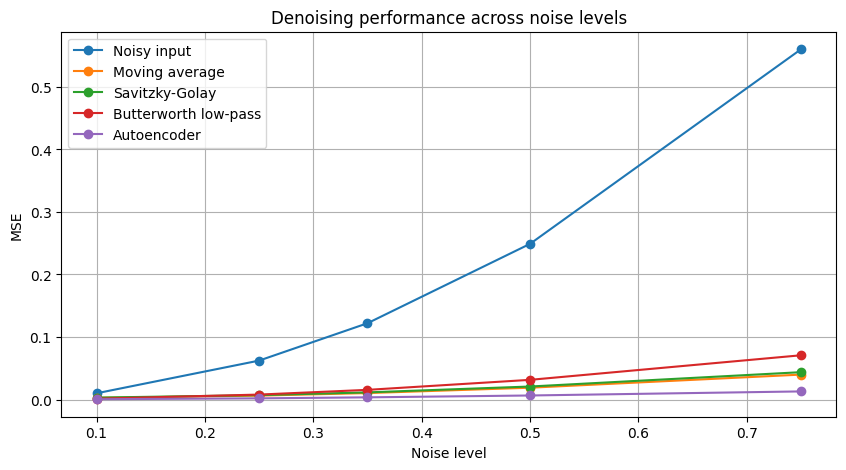

In [ ]:
plt.figure(figsize=(10, 5))

for method in multi_noise_auto_df["Method"].unique():
    subset = multi_noise_auto_df[multi_noise_auto_df["Method"] == method]
    plt.plot(subset["Noise_Level"], subset["MSE"], marker="o", label=method)

plt.xlabel("Noise level")
plt.ylabel("MSE")
plt.title("Denoising performance across noise levels")
plt.legend()
plt.grid(True)

plt.savefig("figures/04_mse_vs_noise_level_with_autoencoder.png", dpi=300, bbox_inches="tight")
plt.show()

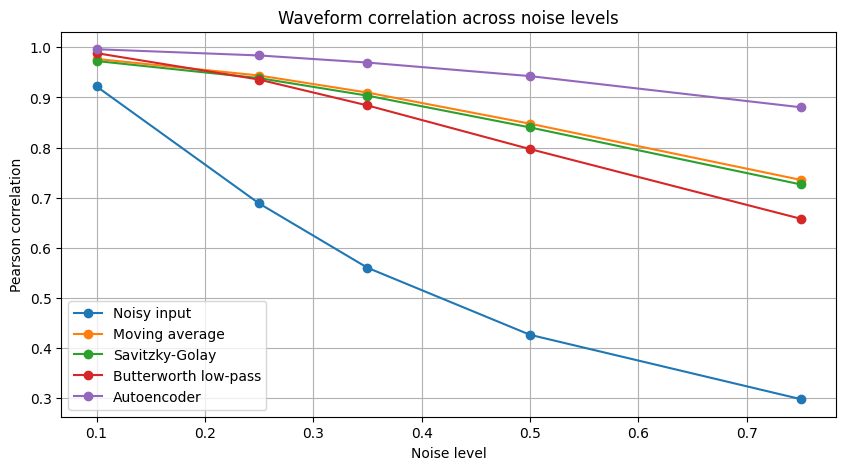

In [ ]:
plt.figure(figsize=(10, 5))

for method in multi_noise_auto_df["Method"].unique():
    subset = multi_noise_auto_df[multi_noise_auto_df["Method"] == method]
    plt.plot(subset["Noise_Level"], subset["Correlation"], marker="o", label=method)

plt.xlabel("Noise level")
plt.ylabel("Pearson correlation")
plt.title("Waveform correlation across noise levels")
plt.legend()
plt.grid(True)

plt.savefig("figures/05_correlation_vs_noise_level_with_autoencoder.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#The autoencoder outperformed all selected classical denoising baselines across all tested Gaussian noise levels, achieving lower MSE and higher waveform correlation, especially under moderate-to-high noise conditions.

In [ ]:
#conclusion: The autoencoder achieved the best denoising performance across all tested noise levels. Compared with moving average, Savitzky-Golay, and Butterworth low-pass filtering, the autoencoder maintained lower MSE and higher Pearson correlation as noise increased. This suggests that the learned model captures the underlying BBH waveform morphology better than fixed classical filters under controlled Gaussian-noise conditions. The improvement is most visible at moderate-to-high noise levels, where classical filters begin to lose waveform shape fidelity.  limitation:This experiment uses simulated BBH waveforms contaminated with Gaussian noise. Real LIGO detector noise is non-Gaussian and non-stationary, so the result should be interpreted as a controlled first-stage denoising benchmark rather than a claim of real-detector deployment.

In [ ]:
results_df.to_csv("data/autoencoder_results_noise_035.csv", index=False)
multi_noise_auto_df.to_csv("data/autoencoder_multi_noise_results.csv", index=False)

model.save("data/bbh_denoising_autoencoder.keras")

print("Saved results and trained model.")

Saved results and trained model.


In [ ]:
import os
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

results_df.to_csv("data/autoencoder_results_noise_035.csv", index=False)
multi_noise_auto_df.to_csv("data/autoencoder_multi_noise_results.csv", index=False)
model.save("data/bbh_denoising_autoencoder.keras")

print("Saved all results and model.")

Saved all results and model.


In [ ]:
auto = results_df[results_df["Method"] == "Autoencoder"].iloc[0]
moving = results_df[results_df["Method"] == "Moving average"].iloc[0]

mse_improvement = ((moving["MSE"] - auto["MSE"]) / moving["MSE"]) * 100
mae_improvement = ((moving["MAE"] - auto["MAE"]) / moving["MAE"]) * 100
corr_improvement = ((auto["Correlation"] - moving["Correlation"]) / moving["Correlation"]) * 100
snr_improvement = auto["SNR_dB"] - moving["SNR_dB"]

print(f"MSE improvement over moving average: {mse_improvement:.2f}%")
print(f"MAE improvement over moving average: {mae_improvement:.2f}%")
print(f"Correlation improvement over moving average: {corr_improvement:.2f}%")
print(f"SNR improvement over moving average: {snr_improvement:.2f} dB")

MSE improvement over moving average: 62.87%
MAE improvement over moving average: 36.25%
Correlation improvement over moving average: 6.52%
SNR improvement over moving average: 4.30 dB


In [ ]:
final_table = results_df.copy()

final_table["MSE"] = final_table["MSE"].round(5)
final_table["MAE"] = final_table["MAE"].round(5)
final_table["Correlation"] = final_table["Correlation"].round(4)
final_table["SNR_dB"] = final_table["SNR_dB"].round(2)

final_table.to_csv("data/final_results_table_noise_035.csv", index=False)

final_table

,Method,MSE,MAE,Correlation,SNR_dB
0,Noisy input,0.12844,0.28507,0.5434,-3.54
1,Moving average,0.01032,0.07662,0.9075,7.41
2,Savitzky-Golay,0.01141,0.07919,0.9005,6.98
3,Butterworth low-pass,0.01737,0.10435,0.8687,5.15
4,Autoencoder,0.00383,0.04884,0.9667,11.72


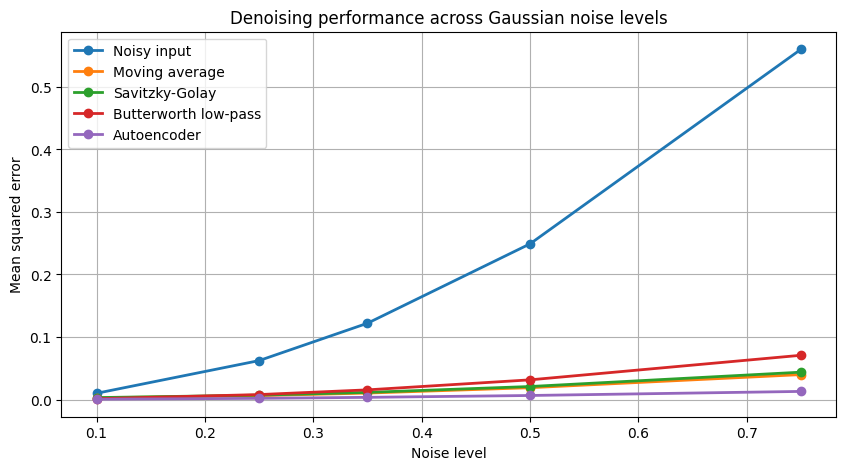

In [ ]:
plt.figure(figsize=(10, 5))

for method in multi_noise_auto_df["Method"].unique():
    subset = multi_noise_auto_df[multi_noise_auto_df["Method"] == method]
    plt.plot(subset["Noise_Level"], subset["MSE"], marker="o", linewidth=2, label=method)

plt.xlabel("Noise level")
plt.ylabel("Mean squared error")
plt.title("Denoising performance across Gaussian noise levels")
plt.legend()
plt.grid(True)

plt.savefig("figures/final_mse_across_noise_levels.png", dpi=300, bbox_inches="tight")
plt.show()

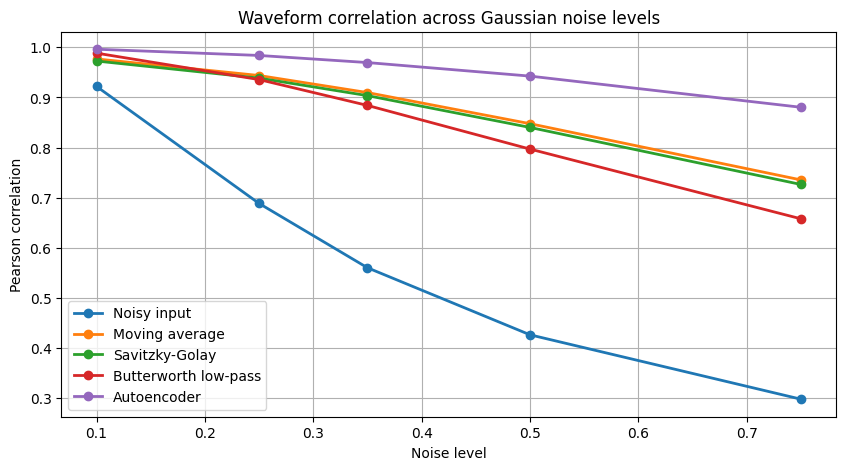

In [ ]:
plt.figure(figsize=(10, 5))

for method in multi_noise_auto_df["Method"].unique():
    subset = multi_noise_auto_df[multi_noise_auto_df["Method"] == method]
    plt.plot(subset["Noise_Level"], subset["Correlation"], marker="o", linewidth=2, label=method)

plt.xlabel("Noise level")
plt.ylabel("Pearson correlation")
plt.title("Waveform correlation across Gaussian noise levels")
plt.legend()
plt.grid(True)

plt.savefig("figures/final_correlation_across_noise_levels.png", dpi=300, bbox_inches="tight")
plt.show()